# 3D cylindrical speaker cabinet

This notebook extends the 2D cabinet example to **3D** by revolving the cross-section through a **full 360°** around the **x-axis** (the horizontal center line of the 2D slice), producing a closed cylindrical cabinet.

Coordinate convention (matching `wood_cabinet_2d.ipynb`):

- **x**: axial direction along the cylinder (the 2D slice **width**, the longer dimension)
- **y, z**: cross-sectional plane; the revolution axis is `y = y_center`, `z = z_center`
- The 2D **height** becomes the cylinder **diameter**; radial distance is `r = sqrt((y − y_center)² + (z − z_center)²)`

The slice `z = z_center` reproduces the 2D geometry. Ports on the left/right walls of the 2D slice become openings on the flat end caps; the top/bottom walls become the curved cylindrical shell.

The cabinet is centered in the domain. The box is sized like the 2D case along x (`3 ×` cabinet width) and `3 ×` cabinet height in the cross-section to leave room for wave propagation outside the cylinder.

### Governing equation (important)

j-Wave solves the **3D Cartesian** wave equation on a rectilinear grid. That is the correct formulation for this 3D problem: the curved cylindrical shell enters through the material map created by revolution, but the Laplacian remains

\[
\nabla^2 p = \frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial y^2} + \frac{\partial^2 p}{\partial z^2}.
\]

Although the geometry is axisymmetric, this is **not** the same as solving an axisymmetric wave equation in cylindrical coordinates \((r, x)\),

\[
\nabla^2 p = \frac{\partial^2 p}{\partial x^2} + \frac{\partial^2 p}{\partial r^2} + \frac{1}{r}\frac{\partial p}{\partial r},
\]

which would allow a cheaper 2D simulation in the meridional \((r, x)\) plane. j-Wave does not implement that operator today.

## Setup

In [1]:
import numpy as np
import pyvista as pv
from jax import jit
from jax import numpy as jnp
from jaxdf import FourierSeries
from matplotlib import pyplot as plt

from jwave.acoustics import TimeWavePropagationSettings, simulate_wave_propagation
from jwave.geometry import Domain, Medium, Sources, TimeAxis
from jwave.signal_processing import apply_ramp, tone_burst

pv.set_jupyter_backend("static")

/Users/rivas/Github/jwave/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Geometry helpers

We first build the same 2D slice as `wood_cabinet_2d.ipynb` in the `(y, x)` plane, then revolve it fully around the x-axis to obtain a closed cylinder.

In [2]:
def build_slice_profile(
    ny: int,
    nx: int,
    cabinet_size: tuple[int, int],
    wall_thickness: int,
    port_height: int,
    c_air: float,
    rho_air: float,
    c_wood: float,
    rho_wood: float,
):
    """Return sound speed and density in the 2D slice (y, x), as in the 2D notebook."""
    cab_h, cab_w = cabinet_size
    y0, x0 = (ny - cab_h) // 2, (nx - cab_w) // 2
    y1, x1 = y0 + cab_h, x0 + cab_w
    port_y0 = (y0 + y1 - port_height) // 2
    port_y1 = port_y0 + port_height

    sound_speed = np.full((ny, nx), c_air, dtype=np.float64)
    density = np.full((ny, nx), rho_air, dtype=np.float64)

    # Top and bottom walls (become the curved cylindrical shell when revolved)
    sound_speed[y0 : y0 + wall_thickness, x0:x1] = c_wood
    sound_speed[y1 - wall_thickness : y1, x0:x1] = c_wood
    density[y0 : y0 + wall_thickness, x0:x1] = rho_wood
    density[y1 - wall_thickness : y1, x0:x1] = rho_wood

    # Left and right end caps
    sound_speed[y0:y1, x0 : x0 + wall_thickness] = c_wood
    sound_speed[y0:y1, x1 - wall_thickness : x1] = c_wood
    density[y0:y1, x0 : x0 + wall_thickness] = rho_wood
    density[y0:y1, x1 - wall_thickness : x1] = rho_wood

    # Ports on the left and right end caps
    sound_speed[port_y0:port_y1, x0 : x0 + wall_thickness] = c_air
    sound_speed[port_y0:port_y1, x1 - wall_thickness : x1] = c_air
    density[port_y0:port_y1, x0 : x0 + wall_thickness] = rho_air
    density[port_y0:port_y1, x1 - wall_thickness : x1] = rho_air

    meta = {
        "y0": y0,
        "y1": y1,
        "x0": x0,
        "x1": x1,
        "port_y0": port_y0,
        "port_y1": port_y1,
        "y_center": (y0 + y1) // 2,
        "x_center": (x0 + x1) // 2,
    }
    return sound_speed, density, meta


def symmetrize_profile(profile: np.ndarray, y_center: int) -> np.ndarray:
    """Mirror the upper meridian so the slice is symmetric about the revolution axis."""
    ny = profile.shape[0]
    symmetric = profile.copy()
    max_r = min(y_center, ny - y_center - 1)
    for r in range(1, max_r + 1):
        symmetric[y_center - r, :] = profile[y_center + r, :]
    return symmetric


def revolve_around_x_axis(
    profile_c: np.ndarray,
    profile_rho: np.ndarray,
):
    """Revolve a (y, x) slice through 360 degrees around the x-axis."""
    ny, nx = profile_c.shape
    nz = ny
    y_center = ny // 2
    z_center = nz // 2

    profile_c = symmetrize_profile(profile_c, y_center)
    profile_rho = symmetrize_profile(profile_rho, y_center)

    ix = np.broadcast_to(np.arange(nx)[:, None, None], (nx, ny, nz))
    iy = np.broadcast_to(np.arange(ny)[None, :, None], (nx, ny, nz))
    iz = np.broadcast_to(np.arange(nz)[None, None, :], (nx, ny, nz))

    r = np.sqrt((iy - y_center) ** 2 + (iz - z_center) ** 2)
    r_idx = np.clip(np.round(r).astype(int), 0, ny - y_center - 1)
    y_row = np.clip(y_center + r_idx, 0, ny - 1)

    sound_speed = profile_c[y_row, ix]
    density = profile_rho[y_row, ix]

    return sound_speed, density, profile_c, profile_rho, int(y_center), int(z_center)


def make_recording_sensor(
    left_mic_x: int,
    right_mic_x: int,
    mic_y: int,
    mic_z: int,
    source_x: int,
    source_y: int,
    z_center: int,
    nx: int,
    ny: int,
    nz: int,
    spatial_stride: int,
):
    """Record microphones + spatially downsampled orthogonal slices every time step."""
    coarse = lambda n: (n + spatial_stride - 1) // spatial_stride
    coarse_nx, coarse_ny, coarse_nz = coarse(nx), coarse(ny), coarse(nz)
    mer_size = coarse_nx * coarse_ny
    cross_size = coarse_ny * coarse_nz
    axial_size = coarse_nx * coarse_nz

    def sensor(p, u, rho):
        grid = p.on_grid[..., 0]
        mics = jnp.array([grid[left_mic_x, mic_y, mic_z], grid[right_mic_x, mic_y, mic_z]])
        meridional = grid[:, :, z_center][::spatial_stride, ::spatial_stride]
        cross = grid[source_x, :, :][::spatial_stride, ::spatial_stride]
        axial = grid[:, source_y, :][::spatial_stride, ::spatial_stride]
        return jnp.concatenate([mics, meridional.ravel(), cross.ravel(), axial.ravel()])

    def unpack(recordings):
        mics = recordings[:, :2]
        offset = 2
        meridional = recordings[:, offset : offset + mer_size].reshape(-1, coarse_nx, coarse_ny)
        offset += mer_size
        cross = recordings[:, offset : offset + cross_size].reshape(-1, coarse_ny, coarse_nz)
        offset += cross_size
        axial = recordings[:, offset : offset + axial_size].reshape(-1, coarse_nx, coarse_nz)
        return mics, meridional, cross, axial

    return sensor, unpack

## Simulation parameters

Dimensions match the 2D notebook physically: `20 mm × 50 mm` cabinet at `0.5 mm` resolution (`CABINET_SIZE = (40, 100)`). The domain is `300 × 120 × 120` grid points — three times the cabinet width along x and three times the cabinet height in the cross-section — with the cabinet centered.

In [3]:
# Material properties
C_AIR, RHO_AIR = 343.0, 1.2
C_WOOD, RHO_WOOD = 3500.0, 700.0

# Grid: x = cylinder axis, y/z = cross-section (same physical size as the 2D notebook)
DX = (0.5e-3, 0.5e-3, 0.5e-3)  # 0.5 mm resolution
CABINET_SIZE = (40, 100)  # 20 mm diameter × 50 mm length
DOMAIN_X = 3 * CABINET_SIZE[1]
DOMAIN_Y = 2 * CABINET_SIZE[0]
DOMAIN_Z = 2 * CABINET_SIZE[0]
WALL_THICKNESS = 6  # 3 mm wood walls
PORT_HEIGHT = 10  # 5 mm port opening
MIC_OFFSET = 40  # 20 mm outside the cabinet walls
SPATIAL_STRIDE = 2  # downsample each stored slice (4× less slice memory per step)
SNAPSHOT_STRIDE = 200  # plot every Nth stored frame (full t_end still simulated)

domain = Domain((DOMAIN_X, DOMAIN_Y, DOMAIN_Z), DX)
nx, ny, nz = domain.N

profile_c, profile_rho, meta = build_slice_profile(
    ny,
    nx,
    CABINET_SIZE,
    WALL_THICKNESS,
    PORT_HEIGHT,
    C_AIR,
    RHO_AIR,
    C_WOOD,
    RHO_WOOD,
)
sound_speed, density, profile_c, profile_rho, y_center, z_center = revolve_around_x_axis(
    profile_c,
    profile_rho,
)

source_x = meta["x_center"]
source_y = meta["y_center"]
source_z = z_center
left_mic_x = meta["x0"] - MIC_OFFSET - 20
right_mic_x = meta["x1"] + MIC_OFFSET - 1 + 20
mic_y = source_y
mic_z = z_center

print(f"3D domain: {domain.N}, dx: {domain.dx}")
print(f"Cabinet slice: y=[{meta['y0']}, {meta['y1']}), x=[{meta['x0']}, {meta['x1']})")
print(f"Ports: y=[{meta['port_y0']}, {meta['port_y1']}) on left/right end caps")
print(f"Source at (x, y, z) = ({source_x}, {source_y}, {source_z})")
print(f"Microphones at x = {left_mic_x} and {right_mic_x}")

3D domain: (300, 80, 80), dx: (0.0005, 0.0005, 0.0005)
Cabinet slice: y=[20, 60), x=[100, 200)
Ports: y=[35, 45) on left/right end caps
Source at (x, y, z) = (150, 40, 40)
Microphones at x = 40 and 259


## Medium visualisation

The 3D fields are plotted as exact grid-aligned slabs on PyVista `ImageData` planes (no VTK geometric slicing, which avoids interpolation artifacts at material boundaries):

1. **Meridional** (`z = z_center`): matches the 2D notebook slice `(y, x)`
2. **Cross-section** (`x = x_center`): circular view in the `y–z` plane
3. **Axial side** (`y = y_center`): view along the cylinder axis in the `x–z` plane

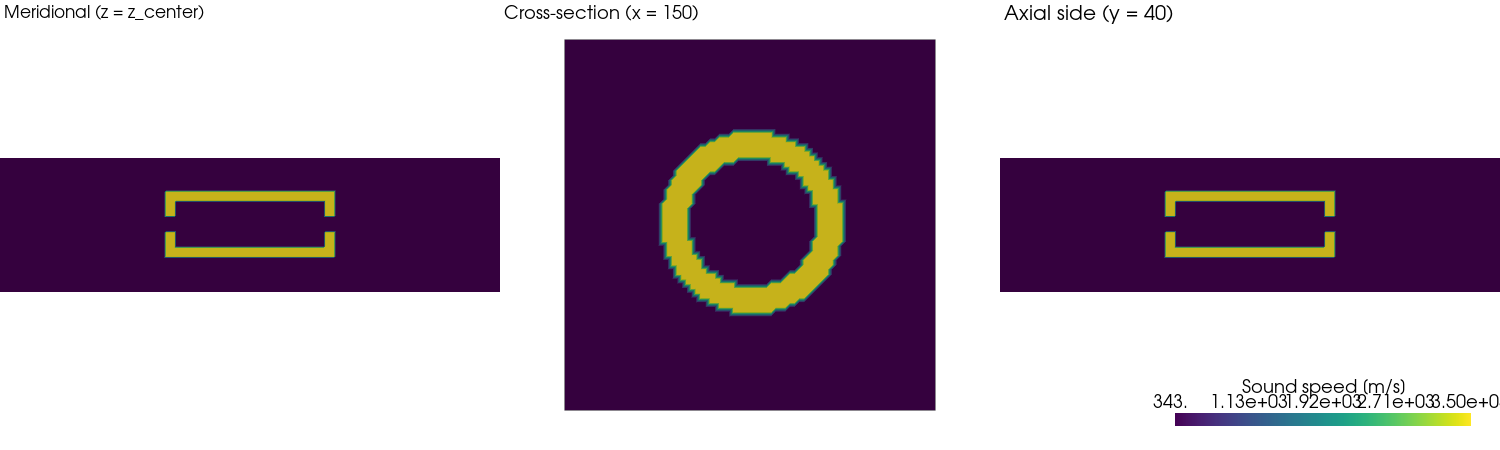

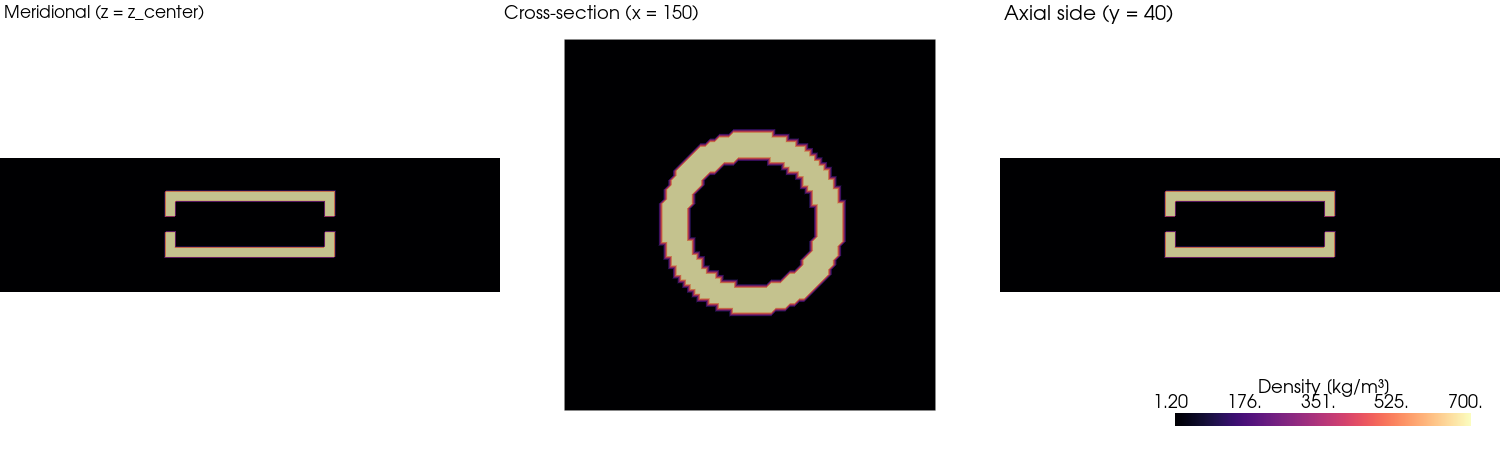

In [4]:
def field_to_pyvista_grid(field: np.ndarray, dx: tuple[float, float, float]) -> pv.ImageData:
    """Map j-Wave array (x, y, z) onto a PyVista ImageData grid."""
    nx, ny, nz = field.shape
    grid = pv.ImageData()
    grid.dimensions = (nx, ny, nz)
    grid.origin = (0.0, 0.0, 0.0)
    grid.spacing = dx
    grid.point_data["values"] = field.ravel(order="F")
    return grid


def slab_to_image_grid(
    slab: np.ndarray,
    spacing: tuple[float, float],
    origin: tuple[float, float, float] = (0.0, 0.0, 0.0),
) -> pv.ImageData:
    """Map a 2D array slab[iy, ix] onto an XY ImageData plane."""
    ny, nx = slab.shape
    grid = pv.ImageData()
    grid.dimensions = (nx, ny, 1)
    grid.spacing = (spacing[0], spacing[1], 1.0)
    grid.origin = origin
    grid.point_data["values"] = np.asarray(slab).T.ravel(order="F")
    return grid


def plot_scalar_slices(
    field,
    title,
    source_x,
    source_y,
    z_center,
    dx,
    vmin=None,
    vmax=None,
    cmap="viridis",
):
    if vmin is None:
        vmin = float(np.min(field))
    if vmax is None:
        vmax = float(np.max(field))

    # Exact grid-aligned slabs (no VTK plane interpolation).
    slabs = [
        ("Meridional (z = z_center)", field[:, :, z_center].T, (dx[0], dx[1])),
        (f"Cross-section (x = {source_x})", field[source_x, :, :], (dx[1], dx[2])),
        (f"Axial side (y = {source_y})", field[:, source_y, :].T, (dx[0], dx[2])),
    ]

    pl = pv.Plotter(shape=(1, 3), window_size=(1500, 450), border=False)
    for col, (label, slab, spacing) in enumerate(slabs):
        pl.subplot(0, col)
        pl.add_mesh(
            slab_to_image_grid(slab, spacing),
            scalars="values",
            cmap=cmap,
            clim=(vmin, vmax),
            show_scalar_bar=(col == 2),
            scalar_bar_args={"title": title},
        )
        pl.add_text(label, font_size=10)
        pl.view_xy()
        pl.camera.zoom(1.2)

    pl.show(title=title)


plot_scalar_slices(
    sound_speed,
    "Sound speed [m/s]",
    source_x,
    source_y,
    z_center,
    DX,
)
plot_scalar_slices(
    density,
    "Density [kg/m³]",
    source_x,
    source_y,
    z_center,
    DX,
    cmap="magma",
)


In [5]:
grid = field_to_pyvista_grid(sound_speed, DX)
grid.save("sound_speed.vtk")

In [6]:
medium = Medium(
    domain=domain,
    sound_speed=FourierSeries(np.expand_dims(sound_speed, -1), domain),
    density=FourierSeries(np.expand_dims(density, -1), domain),
    pml_size=10,
)

time_axis = TimeAxis.from_medium(medium, cfl=0.2, t_end=1.0e-3)
# Progress uses jax.debug.callback (safe with os.write, not tqdm).
# First @jit call also compiles XLA — you may see a one-off "constant folding" warning.
settings = TimeWavePropagationSettings(show_progress=True, progress_interval_pct=1.0)
print(time_axis)

## Source

Text(0, 0.5, 'amplitude')

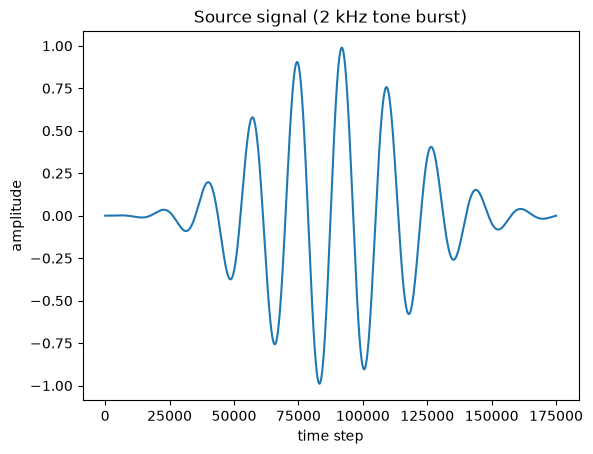

In [7]:
sample_freq = 1.0 / time_axis.dt
source_signal = apply_ramp(
    tone_burst(sample_freq, 2000.0, 10),
    time_axis.dt,
    2000.0,
)

sources = Sources(
    positions=((source_x,), (source_y,), (source_z,)),
    signals=jnp.expand_dims(source_signal, 0),
    dt=time_axis.dt,
    domain=domain,
)

recording_sensor, unpack_recordings = make_recording_sensor(
    left_mic_x,
    right_mic_x,
    mic_y,
    mic_z,
    source_x,
    source_y,
    z_center,
    nx,
    ny,
    nz,
    SPATIAL_STRIDE,
)

plt.plot(source_signal)
plt.title("Source signal (2 kHz tone burst)")
plt.xlabel("time step")
plt.ylabel("amplitude")

## Simulation

One run over the **full** `t_end` records microphone traces and three **spatially downsampled** orthogonal slices (`SPATIAL_STRIDE`) at every time step — much less memory than the full `(Nt, Nx, Ny, Nz)` volume. Snapshots below use `SNAPSHOT_STRIDE` in time only; the whole interval is still simulated.

### Why not a cheaper 2D run?

The geometry is axisymmetric, but **a 2D Cartesian slice is not an equivalent physical model**:

| Model | Coordinates | Laplacian | Matches this 3D cabinet? |
|-------|-------------|-----------|----------------------------|
| `wood_cabinet_2d.ipynb` | Cartesian \((y, x)\) | \(\partial_{xx} + \partial_{yy}\) | Same **meridional geometry** only |
| Axisymmetric (not in j-Wave) | cylindrical \((r, x)\) | \(\partial_{xx} + \partial_{rr} + \frac{1}{r}\partial_r\) | Would be the correct **reduced** model |
| This notebook | Cartesian \((x, y, z)\) | \(\partial_{xx} + \partial_{yy} + \partial_{zz}\) | **Correct** full 3D acoustics |

So the 2D notebook is useful as a rectangular-cabinet reference and for building the revolved geometry, but it does **not** solve the axisymmetric cylindrical wave equation. The 3D run is required for faithful acoustics here.

For exploratory runs, reduce `t_end` first; the fine `0.5 mm` grid makes each step expensive (~35k steps for `t_end = 1 ms`).

In [ ]:
import time

@jit
def run_simulation(sources):
    return simulate_wave_propagation(
        medium,
        time_axis,
        sources=sources,
        sensors=recording_sensor,
        settings=settings,
    )


t0 = time.perf_counter()
recordings = run_simulation(sources)
print(f"Simulation finished in {time.perf_counter() - t0:.1f} s")
mic_recordings, meridional_slices, cross_slices, axial_slices = unpack_recordings(recordings)
left_pressure = mic_recordings[:, 0]
right_pressure = mic_recordings[:, 1]
slice_bytes = (
    meridional_slices.nbytes + cross_slices.nbytes + axial_slices.nbytes
)
n_frames = int(time_axis.Nt) // SNAPSHOT_STRIDE + 1
print(
    f"Coarse slices stored: mer {meridional_slices.shape}, "
    f"cross {cross_slices.shape}, axial {axial_slices.shape} "
    f"({slice_bytes / 1e6:.0f} MB total); ~{n_frames} snapshot frames"
)

E0910 11:58:59.169727 1896364 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce_max.7 = f32[] reduce(%constant.169, %constant.171), dimensions={0,1,2,3}, to_apply=%region_0.1, metadata={op_name="jit(run_simulation)/reduce_max" stack_frame_id=10}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0910 11:58:59.695292 1896362 slow_operation_alarm.cc:140] The operation took 1.526826s
Constant folding an instruction is taking > 1s:

  %reduce_max.7 = f32[] reduce(%constant.169, %constant.171), dimensions={0,1,2,3}, to_apply=%region_0.1, metadata={op_name="jit(run_simulation)/reduce_max" stack_frame_id=10}

Th

## Microphone comparison

Peak |p| left mic: 0.000000
Peak |p| right mic: 0.000000
Relative difference: 95.79%


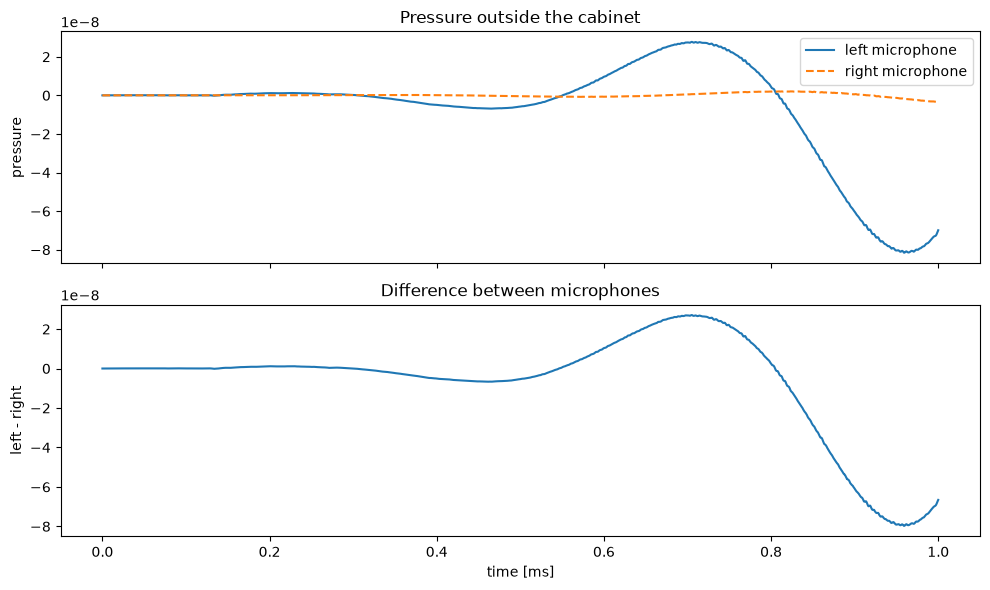

In [ ]:
time = time_axis.to_array()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(time * 1e3, left_pressure, label="left microphone")
axes[0].plot(time * 1e3, right_pressure, label="right microphone", linestyle="--")
axes[0].set_ylabel("pressure")
axes[0].set_title("Pressure outside the cabinet")
axes[0].legend()

axes[1].plot(time * 1e3, left_pressure - right_pressure)
axes[1].set_xlabel("time [ms]")
axes[1].set_ylabel("left - right")
axes[1].set_title("Difference between microphones")

plt.tight_layout()

peak_left = jnp.max(jnp.abs(left_pressure))
peak_right = jnp.max(jnp.abs(right_pressure))
print(f"Peak |p| left mic: {peak_left:.6f}")
print(f"Peak |p| right mic: {peak_right:.6f}")
print(
    f"Relative difference: {100 * jnp.abs(peak_left - peak_right) / jnp.maximum(peak_left, peak_right):.2f}%"
)

## Pressure slices

Plot evenly spaced frames from the **same** simulation (full `t_end`). Slices are stored with `SPATIAL_STRIDE`; only every `SNAPSHOT_STRIDE`-th frame is drawn.

/var/folders/wj/ljx542lx73z3721_ddn_zwtc0000gp/T/ipykernel_73838/1990655103.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


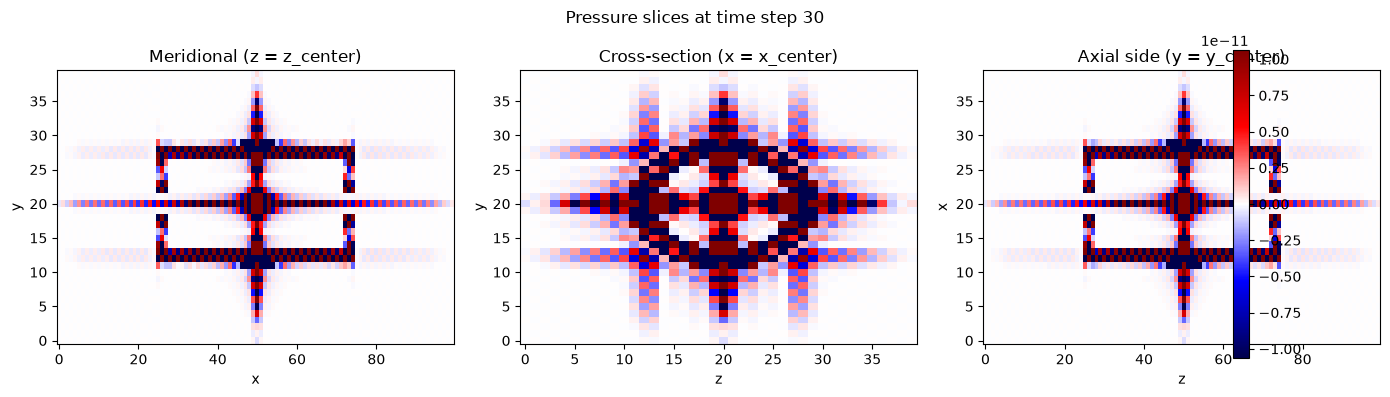

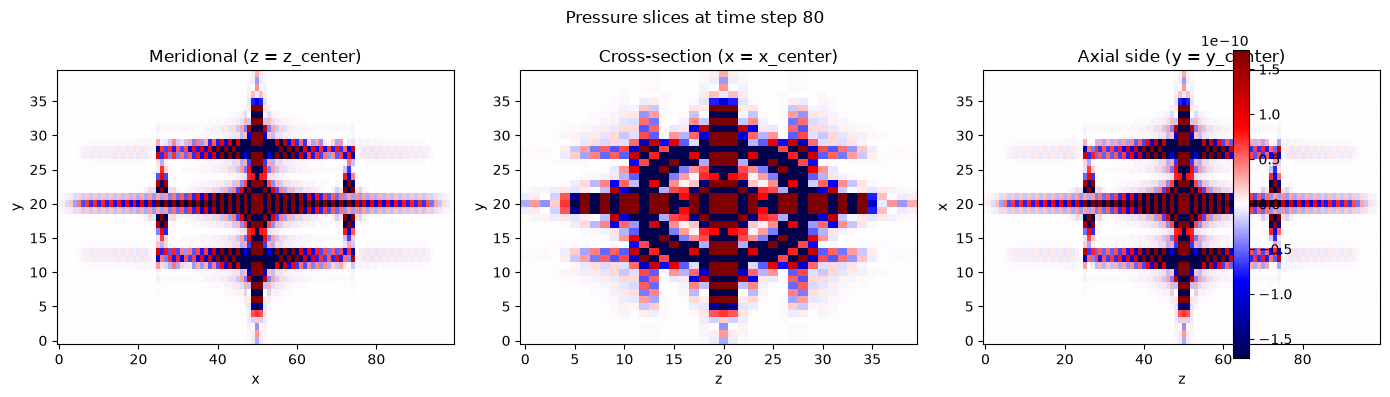

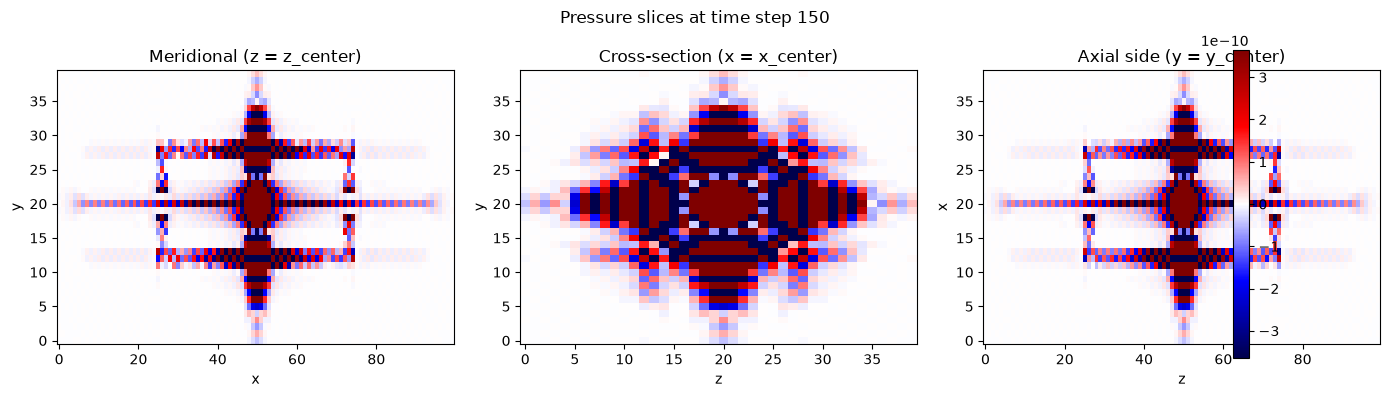

In [ ]:
def plot_pressure_slices(meridional, cross, axial, title):
    vmax = jnp.percentile(
        jnp.abs(jnp.concatenate([meridional.ravel(), cross.ravel(), axial.ravel()])),
        99,
    )
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    im0 = axes[0].imshow(
        meridional.T,
        origin="lower",
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[0].set_title("Meridional (z = z_center)")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    im1 = axes[1].imshow(
        cross.T,
        origin="lower",
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[1].set_title("Cross-section (x = x_center)")
    axes[1].set_xlabel("z")
    axes[1].set_ylabel("y")

    im2 = axes[2].imshow(
        axial.T,
        origin="lower",
        aspect="auto",
        cmap="seismic",
        vmin=-vmax,
        vmax=vmax,
    )
    axes[2].set_title("Axial side (y = y_center)")
    axes[2].set_xlabel("z")
    axes[2].set_ylabel("x")

    fig.suptitle(title)
    fig.colorbar(im2, ax=axes.ravel().tolist(), fraction=0.02)
    plt.tight_layout()


snapshot_times = time_axis.to_array()[::SNAPSHOT_STRIDE]
print(
    f"Plotting {len(snapshot_times)} frames over t ∈ [0, {time_axis.t_end * 1e3:.2f}] ms"
)

for meridional, cross, axial, t in zip(
    meridional_slices[::SNAPSHOT_STRIDE],
    cross_slices[::SNAPSHOT_STRIDE],
    axial_slices[::SNAPSHOT_STRIDE],
    snapshot_times,
):
    plot_pressure_slices(
        meridional,
        cross,
        axial,
        f"Pressure slices at t = {t * 1e3:.3f} ms",
    )

## 2D slice check

The meridional slice of the 3D medium should match the 2D notebook profile.

Slices identical: True


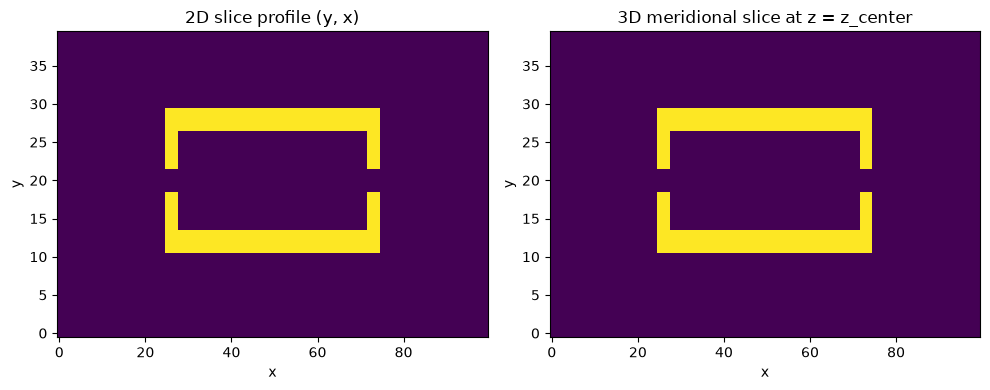

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(profile_c, origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title("2D slice profile (y, x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

axes[1].imshow(sound_speed[:, :, z_center].T, origin="lower", aspect="auto", cmap="viridis")
axes[1].set_title("3D meridional slice at z = z_center")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
print("Slices identical:", np.allclose(profile_c, sound_speed[:, :, z_center].T))